# QS World University Rankings — Exploratory Data Analysis

This notebook uses the **cleaned, processed data** produced by `pipeline.py` — never the raw scraped files.

**Data flow:**
```
scraper.py  →  data/raw/*.csv                    (raw, uncleaned)
pipeline.py →  data/processed/rankings_merged.csv  (cleaned & joined ← used here)
            →  data/processed/qs_rankings.db        (SQLite, same cleaned data)
```

**Visualisations produced:**
1. Geographic heatmap — Top 100 universities per country
2. Metric correlation matrix
3. Research vs Learning Experience by continent
4. Top 20 universities by overall score
5. Missing-value heatmap (data quality check)
6. Summary statistics

> **Pre-requisite:** Run `python scraper.py` then `python pipeline.py` before opening this notebook.

In [9]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns

# ── Load from cleaned merged CSV (primary) ───────────────────────────────────
# pipeline.py writes this file after cleaning; it is the joined, processed dataset.
MERGED_CSV = Path("data/processed/rankings_merged.csv")
DB_PATH    = Path("data/processed/qs_rankings.db")

if MERGED_CSV.exists():
    df = pd.read_csv(MERGED_CSV)
    print(f"✅ Loaded cleaned data from {MERGED_CSV}")
elif DB_PATH.exists():
    # Fallback: read from SQLite (same cleaned data, just different format)
    conn = sqlite3.connect(DB_PATH)
    df = pd.read_sql("SELECT * FROM v_full_rankings ORDER BY rank", conn)
    conn.close()
    print(f"✅ Loaded cleaned data from {DB_PATH} (CSV not found, used SQLite)")
else:
    raise FileNotFoundError(
        "No cleaned data found.\n"
        "Run:  python scraper.py\n"
        "Then: python pipeline.py"
    )

print(f"\nShape: {df.shape[0]} universities × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
df.head()

✅ Loaded cleaned data from data\processed\rankings_merged.csv

Shape: 1504 universities × 23 columns
Columns: ['rank', 'university_name', 'country', 'overall_score', 'citations_per_faculty', 'academic_reputation', 'employer_reputation', 'intl_faculty_ratio', 'intl_student_ratio', 'detail_url', 'continent', 'cleaned_at', 'research_discovery', 'learning_experience', 'employability', 'global_engagement', 'sustainability', 'description', 'university_type', 'founded_year', 'total_students', 'student_faculty_ratio', 'review_snippets']


,rank,university_name,country,overall_score,citations_per_faculty,academic_reputation,employer_reputation,intl_faculty_ratio,intl_student_ratio,detail_url,...,learning_experience,employability,global_engagement,sustainability,description,university_type,founded_year,total_students,student_faculty_ratio,review_snippets
0,1,Massachusetts Institute of Technology (MIT),United States,100.0,100.0,100.0,100.0,100.0,91.6,https://www.topuniversities.com/universities/m...,...,NaN,NaN,NaN,NaN,“Mind and Hand” is the thought-provoking motto...,NaN,NaN,NaN,NaN,NaN
1,2,Imperial College London,United Kingdom,99.4,95.0,99.6,100.0,100.0,100.0,https://www.topuniversities.com/universities/i...,...,NaN,NaN,NaN,NaN,Join our mailing list to receive useful inform...,NaN,NaN,NaN,NaN,NaN
2,3,Stanford University,United States,98.9,99.7,100.0,100.0,94.2,73.5,https://www.topuniversities.com/universities/s...,...,NaN,NaN,NaN,NaN,"Stanford University is a place of discovery, c...",NaN,NaN,NaN,NaN,NaN
3,4,University of Oxford,United Kingdom,97.9,91.0,100.0,100.0,98.8,98.6,https://www.topuniversities.com/universities/u...,...,NaN,NaN,NaN,NaN,The University of Oxford is the oldest univers...,NaN,NaN,NaN,NaN,NaN
4,5,Harvard University,United States,97.7,100.0,100.0,100.0,79.1,81.4,https://www.topuniversities.com/universities/h...,...,NaN,NaN,NaN,NaN,"Established in 1636, Harvard is the oldest hig...",NaN,NaN,NaN,NaN,NaN


── Data types & non-null counts ─────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1504 entries, 0 to 1503
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   rank                   1504 non-null   int64  
 1   university_name        1504 non-null   object 
 2   country                1504 non-null   object 
 3   overall_score          705 non-null    float64
 4   citations_per_faculty  1504 non-null   float64
 5   academic_reputation    1504 non-null   float64
 6   employer_reputation    1504 non-null   float64
 7   intl_faculty_ratio     1417 non-null   float64
 8   intl_student_ratio     1467 non-null   float64
 9   detail_url             1504 non-null   object 
 10  continent              1504 non-null   object 
 11  cleaned_at             1504 non-null   object 
 12  research_discovery     0 non-null      float64
 13  learning_experience    0 non-null     

,missing_count,missing_%
learning_experience,1504,100.0
research_discovery,1504,100.0
employability,1504,100.0
student_faculty_ratio,1504,100.0
sustainability,1504,100.0
global_engagement,1504,100.0
review_snippets,1504,100.0
total_students,1504,100.0
founded_year,1496,99.5
university_type,1487,98.9



── Numeric score ranges (cleaned data — should all be 0–100) ────────


,overall_score,citations_per_faculty,academic_reputation,employer_reputation,intl_faculty_ratio,intl_student_ratio
count,705.00,1504.00,1504.00,1504.00,1417.00,1467.00
mean,46.70,30.48,25.75,26.91,36.27,33.33
std,18.84,29.72,24.49,25.49,35.23,32.77
min,25.10,1.00,1.00,1.00,1.00,1.00
25%,30.90,6.00,8.78,8.50,6.60,5.95
50%,41.50,18.05,16.00,16.40,20.10,19.40
75%,58.80,50.02,32.55,37.35,66.10,56.70
max,100.00,100.00,100.00,100.00,100.00,100.00


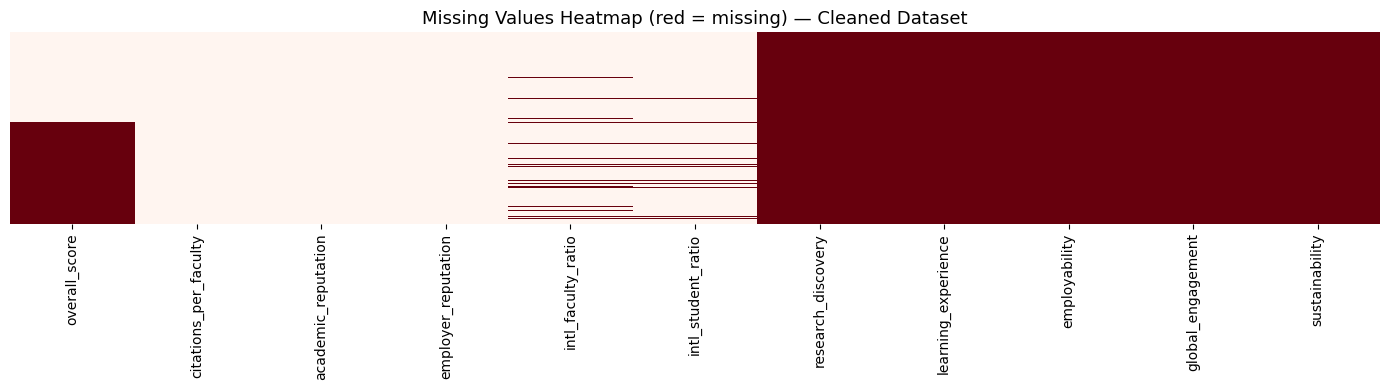


⚠️  Columns with no scraped data yet (all null): ['research_discovery', 'learning_experience', 'employability', 'global_engagement', 'sustainability']
   Re-run scraper.py with a larger MAX_LAYER_B to populate these.


In [10]:
print("── Data types & non-null counts ─────────────────────────────────────")
df.info()

print("\n── Missing values per column ────────────────────────────────────────")
missing = df.isnull().sum().rename("missing_count")
missing_pct = (df.isnull().mean() * 100).rename("missing_%").round(1)
display(pd.concat([missing, missing_pct], axis=1)[missing > 0].sort_values("missing_count", ascending=False))

print("\n── Numeric score ranges (cleaned data — should all be 0–100) ────────")
numeric_cols = [
    "overall_score", "citations_per_faculty", "academic_reputation",
    "employer_reputation", "intl_faculty_ratio", "intl_student_ratio",
    "research_discovery", "learning_experience", "employability",
    "global_engagement", "sustainability",
]
available = [c for c in numeric_cols if c in df.columns and df[c].notna().any()]
if not available:
    print("  [!] No numeric score columns have non-null data.")
else:
    display(df[available].describe().round(2))

# Missing-value heatmap (data quality overview)
all_numeric = [c for c in numeric_cols if c in df.columns]
plt.figure(figsize=(14, 4))
sns.heatmap(df[all_numeric].isnull(), cbar=False, yticklabels=False,
            cmap="Reds", linewidths=0)
plt.title("Missing Values Heatmap (red = missing) — Cleaned Dataset", fontsize=13)
plt.tight_layout()
plt.show()

if len(available) < len(all_numeric):
    missing_detail = [c for c in all_numeric if c not in available]
    print(f"\n⚠️  Columns with no scraped data yet (all null): {missing_detail}")
    print("   Re-run scraper.py with a larger MAX_LAYER_B to populate these.")


## 1. Geographic Heatmap — Top 100 Universities per Country

In [11]:
top100 = df[df["rank"] <= 100].copy()
count_by_country = (
    top100.groupby("country")
    .size()
    .reset_index(name="university_count")
    .sort_values("university_count", ascending=False)
)

fig = px.choropleth(
    count_by_country,
    locations="country",
    locationmode="country names",
    color="university_count",
    color_continuous_scale="Blues",
    title="Count of Top 100 Universities by Country",
    labels={"university_count": "# Universities"},
)
fig.update_layout(geo=dict(showframe=False, showcoastlines=True))
fig.show()

print("\nTop 10 countries by university count in top 100:")
print(count_by_country.head(10).to_string(index=False))


Top 10 countries by university count in top 100:
         country  university_count
   United States                26
  United Kingdom                17
       Australia                 9
         Germany                 5
   Hong Kong SAR                 5
China (Mainland)                 5
           Japan                 4
          France                 4
          Canada                 4
          Sweden                 3


## 2. Metric Correlation Matrix

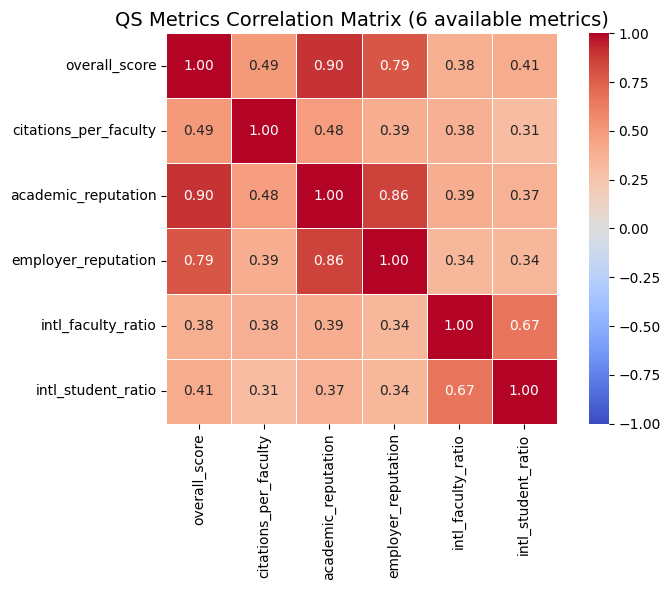


⚠️  Excluded (no data yet): ['research_discovery', 'learning_experience', 'employability', 'global_engagement', 'sustainability']


In [12]:
numeric_cols = [
    "overall_score", "citations_per_faculty", "academic_reputation",
    "employer_reputation", "intl_faculty_ratio", "intl_student_ratio",
    "research_discovery", "learning_experience", "employability",
    "global_engagement", "sustainability",
]
# Only include columns that are present AND have at least some non-null data
available = [c for c in numeric_cols if c in df.columns and df[c].notna().any()]

if len(available) < 2:
    print("⚠️  Not enough numeric columns with data to compute a correlation matrix.")
else:
    corr = df[available].dropna(how="all").corr()

    plt.figure(figsize=(max(8, len(available)), max(6, len(available) - 1)))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1, vmax=1,
        square=True,
        linewidths=0.5,
    )
    plt.title(f"QS Metrics Correlation Matrix ({len(available)} available metrics)", fontsize=14)
    plt.tight_layout()
    plt.show()

    if len(available) < len(numeric_cols):
        missing = [c for c in numeric_cols if c not in available]
        print(f"\n⚠️  Excluded (no data yet): {missing}")


## 3. Top 20 Universities by Overall Score

In [13]:
top20 = df[df["overall_score"].notna()].nsmallest(20, "rank")

fig = px.bar(
    top20,
    x="overall_score",
    y="university_name",
    orientation="h",
    color="continent",
    title="Top 20 Universities — Overall Score",
    labels={"overall_score": "Overall Score", "university_name": ""},
    text="overall_score",
)
fig.update_traces(texttemplate="%{text:.1f}", textposition="outside")
fig.update_layout(
    yaxis={"categoryorder": "total ascending"},
    height=600,
)
fig.show()

## 4. Summary Statistics

In [14]:
numeric_cols = [
    "overall_score", "citations_per_faculty", "academic_reputation",
    "employer_reputation", "intl_faculty_ratio", "intl_student_ratio",
    "research_discovery", "learning_experience", "employability",
    "global_engagement", "sustainability",
]
available = [c for c in numeric_cols if c in df.columns and df[c].notna().any()]
summary = df[available].describe().T
summary.style.background_gradient(cmap="YlGn", subset=["mean", "50%"]).format("{:.2f}")


,count,mean,std,min,25%,50%,75%,max
overall_score,705.00,46.70,18.84,25.10,30.90,41.50,58.80,100.00
citations_per_faculty,1504.00,30.48,29.72,1.00,6.00,18.05,50.02,100.00
academic_reputation,1504.00,25.75,24.49,1.00,8.78,16.00,32.55,100.00
employer_reputation,1504.00,26.91,25.49,1.00,8.50,16.40,37.35,100.00
intl_faculty_ratio,1417.00,36.27,35.23,1.00,6.60,20.10,66.10,100.00
intl_student_ratio,1467.00,33.33,32.77,1.00,5.95,19.40,56.70,100.00


In [15]:
# Country distribution of all scraped universities
country_dist = df["country"].value_counts().head(20).reset_index()
country_dist.columns = ["country", "count"]

fig = px.bar(
    country_dist,
    x="count",
    y="country",
    orientation="h",
    title="Top 20 Countries by Number of Ranked Universities",
    labels={"count": "Number of Universities", "country": ""},
    color="count",
    color_continuous_scale="Teal",
)
fig.update_layout(yaxis={"categoryorder": "total ascending"})
fig.show()